In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
data = pd.read_csv("Mall Customers.csv")
data.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [3]:
data.columns = data.columns.str.strip()

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Education               200 non-null    object
 4   Marital Status          200 non-null    object
 5   Annual Income (k$)      200 non-null    int64 
 6   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 11.1+ KB


In [5]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
Annual_Income_by_gender = data.groupby("Gender")["Annual Income (k$)"].mean()
print(Annual_Income_by_gender)

Gender
F    59.250000
M    62.227273
Name: Annual Income (k$), dtype: float64


In [7]:
Spending_Score_by_gender = data.groupby("Gender")["Spending Score (1-100)"].mean()
print(Spending_Score_by_gender)

Gender
F    51.526786
M    48.511364
Name: Spending Score (1-100), dtype: float64


In [8]:
data['Education'].value_counts()

Education
Graduate         67
High School      40
Uneducated       31
Unknown          26
College          17
Doctorate        11
Post-Graduate     8
Name: count, dtype: int64

In [9]:
Education_by_gender = data.groupby("Gender")["Education"].value_counts()
print(Education_by_gender)

Gender  Education    
F       Graduate         41
        High School      25
        Uneducated       11
        Unknown          10
        Doctorate         9
        College           8
        Post-Graduate     8
M       Graduate         26
        Uneducated       20
        Unknown          16
        High School      15
        College           9
        Doctorate         2
Name: count, dtype: int64


In [10]:
ohe = OneHotEncoder(sparse_output=False)

features = ["Gender", "Marital Status"]

data_to_encode = data[features]

encoded_array = ohe.fit_transform(data_to_encode)

encoded_cols = ohe.get_feature_names_out(features)

df_encoded_parts = pd.DataFrame(encoded_array, columns=encoded_cols)

df_remaining = data.drop(columns=features)

data = pd.concat([df_remaining, df_encoded_parts], axis=1)

data.head()

,CustomerID,Age,Education,Annual Income (k$),Spending Score (1-100),Gender_F,Gender_M,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Marital Status_Unknown
0,1,19,High School,15,39,0.0,1.0,0.0,1.0,0.0,0.0
1,2,21,Graduate,15,81,0.0,1.0,0.0,0.0,1.0,0.0
2,3,20,Graduate,16,6,1.0,0.0,0.0,1.0,0.0,0.0
3,4,23,High School,16,77,1.0,0.0,0.0,0.0,0.0,1.0
4,5,31,Uneducated,17,40,1.0,0.0,0.0,1.0,0.0,0.0


In [11]:
education_order = [
    'Unknown', 
    'Uneducated', 
    'High School', 
    'College', 
    'Graduate', 
    'Post-Graduate', 
    'Doctorate'
]

In [12]:
oe = OrdinalEncoder(categories=[education_order])

data['Education'] = oe.fit_transform(data[['Education']])

print(data['Education'].value_counts())
data.head()

Education
4.0    67
2.0    40
1.0    31
0.0    26
3.0    17
6.0    11
5.0     8
Name: count, dtype: int64


,CustomerID,Age,Education,Annual Income (k$),Spending Score (1-100),Gender_F,Gender_M,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Marital Status_Unknown
0,1,19,2.0,15,39,0.0,1.0,0.0,1.0,0.0,0.0
1,2,21,4.0,15,81,0.0,1.0,0.0,0.0,1.0,0.0
2,3,20,4.0,16,6,1.0,0.0,0.0,1.0,0.0,0.0
3,4,23,2.0,16,77,1.0,0.0,0.0,0.0,0.0,1.0
4,5,31,1.0,17,40,1.0,0.0,0.0,1.0,0.0,0.0


In [13]:
data = data.drop(columns=['CustomerID'])
data.head()

,Age,Education,Annual Income (k$),Spending Score (1-100),Gender_F,Gender_M,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Marital Status_Unknown
0,19,2.0,15,39,0.0,1.0,0.0,1.0,0.0,0.0
1,21,4.0,15,81,0.0,1.0,0.0,0.0,1.0,0.0
2,20,4.0,16,6,1.0,0.0,0.0,1.0,0.0,0.0
3,23,2.0,16,77,1.0,0.0,0.0,0.0,0.0,1.0
4,31,1.0,17,40,1.0,0.0,0.0,1.0,0.0,0.0


In [14]:
scaler = StandardScaler()

# 3. Fit and transform the data
scaled_features = scaler.fit_transform(data)

# 4. Convert back to a DataFrame to keep it clean and readable
df_scaled = pd.DataFrame(scaled_features, columns=data.columns)

# Verify the scaled data (means should be ~0 and standard deviations should be ~1)
df_scaled.head()

,Age,Education,Annual Income (k$),Spending Score (1-100),Gender_F,Gender_M,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Marital Status_Unknown
0,-1.424569,-0.400861,-1.738999,-0.434801,-1.128152,1.128152,-0.252646,0.886405,-0.662457,-0.284747
1,-1.281035,0.778142,-1.738999,1.195704,-1.128152,1.128152,-0.252646,-1.128152,1.509533,-0.284747
2,-1.352802,0.778142,-1.700830,-1.715913,0.886405,-0.886405,-0.252646,0.886405,-0.662457,-0.284747
3,-1.137502,-0.400861,-1.700830,1.040418,0.886405,-0.886405,-0.252646,-1.128152,-0.662457,3.511885
4,-0.563369,-0.990362,-1.662660,-0.395980,0.886405,-0.886405,-0.252646,0.886405,-0.662457,-0.284747


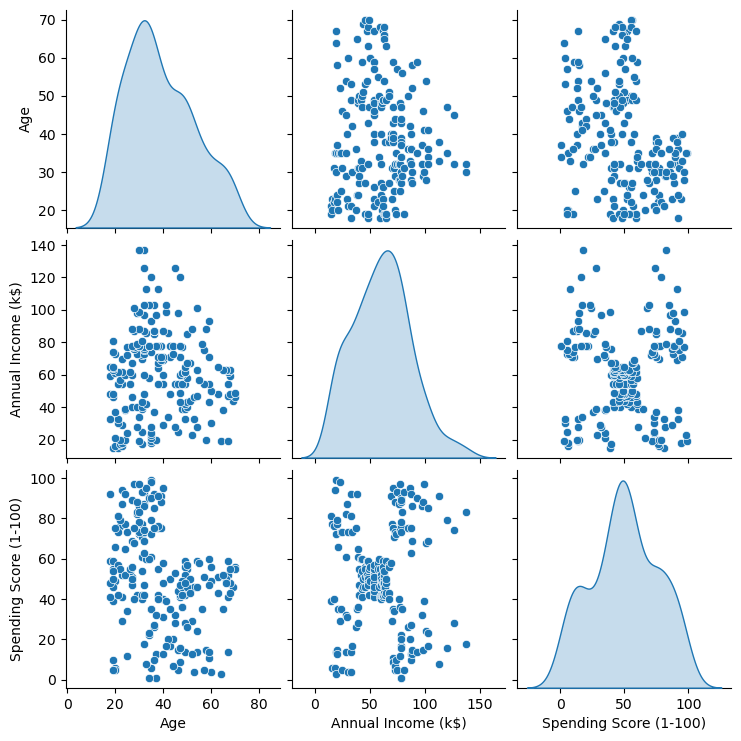

In [15]:
sns.pairplot(data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']], diag_kind='kde', height=2.5)
plt.show()

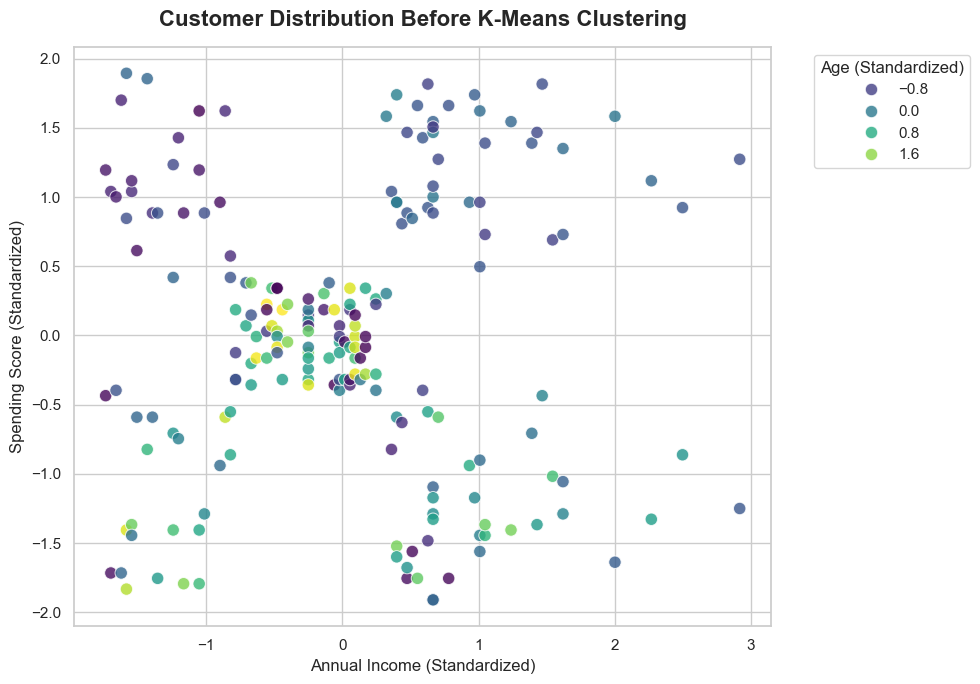

In [16]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 7))

scatter = sns.scatterplot(
    data=df_scaled, 
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Age',            # Colors the points by Age to add a 3rd dimension
    palette='viridis',     # Beautiful, perceptually uniform color palette
    alpha=0.8,            # Slightly translucent to see overlapping points
    edgecolor='w',        # White borders around points to make them pop
    s=80                  # Size of the data points
)

plt.title('Customer Distribution Before K-Means Clustering', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Annual Income (Standardized)', fontsize=12)
plt.ylabel('Spending Score (Standardized)', fontsize=12)

plt.legend(title='Age (Standardized)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

C:\Users\Saqib\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Saqib\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Saqib\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Saqib\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

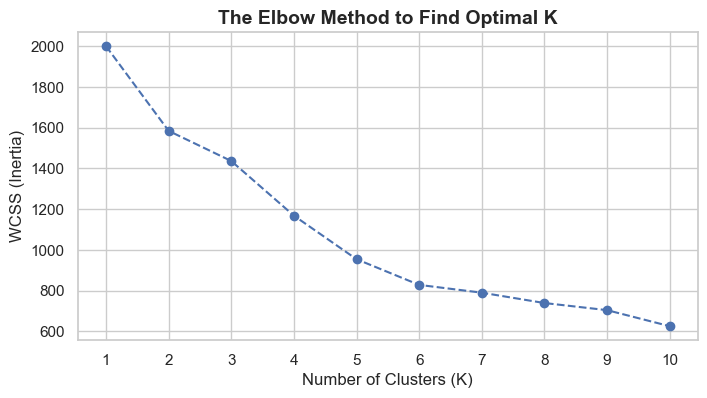

In [17]:
# 1. Use the Elbow Method to find the optimal number of clusters
wcss = []  # Within-Cluster Sum of Squares
k_range = range(1, 11)

for k in k_range:
    # Using df_scaled (from our previous normalization step)
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method to Find Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(k_range)
plt.show()

In [19]:
# Choose the optimal K based on the elbow plot above
optimal_k = 5 

# Initialize and fit the final model
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
cluster_labels = kmeans_final.fit_predict(df_scaled) # or .fit_predict

# Add the cluster assignments back to both your original and scaled dataframes
data['Cluster'] = kmeans_final.labels_
df_scaled['Cluster'] = kmeans_final.labels_

# Check how many customers landed in each cluster
print("Customer count per cluster:")
print(data['Cluster'].value_counts())

Customer count per cluster:
Cluster
1    62
0    61
3    50
2    15
4    12
Name: count, dtype: int64


C:\Users\Saqib\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


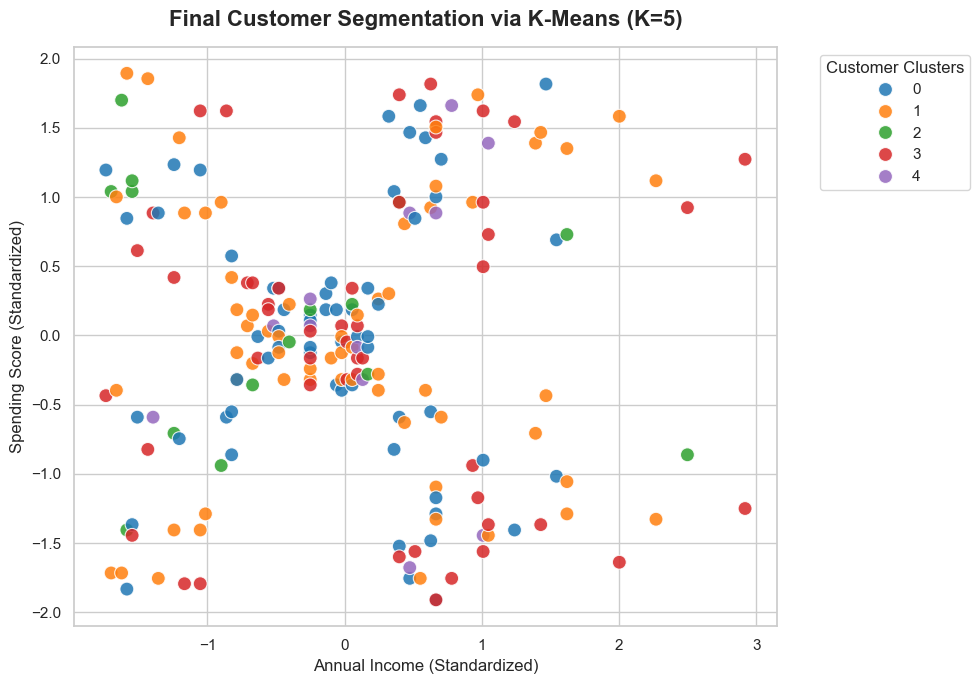

In [20]:
sns.set_theme(style="whitegrid")

# Create the figure
plt.figure(figsize=(10, 7))

# Create the scatter plot using the new 'Cluster' column for color (hue)
scatter = sns.scatterplot(
    data=df_scaled, 
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Cluster',          # Colors points by their assigned cluster
    palette='tab10',        # Distinct color palette for categorical clusters
    alpha=0.85,            # Slight translucency to see overlapping points
    edgecolor='w',          # White borders to make points pop
    s=100                   # Marker size
)

# Customize titles and labels
plt.title('Final Customer Segmentation via K-Means (K=5)', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Annual Income (Standardized)', fontsize=12)
plt.ylabel('Spending Score (Standardized)', fontsize=12)

# Place the legend neatly outside the plotting area
plt.legend(title='Customer Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

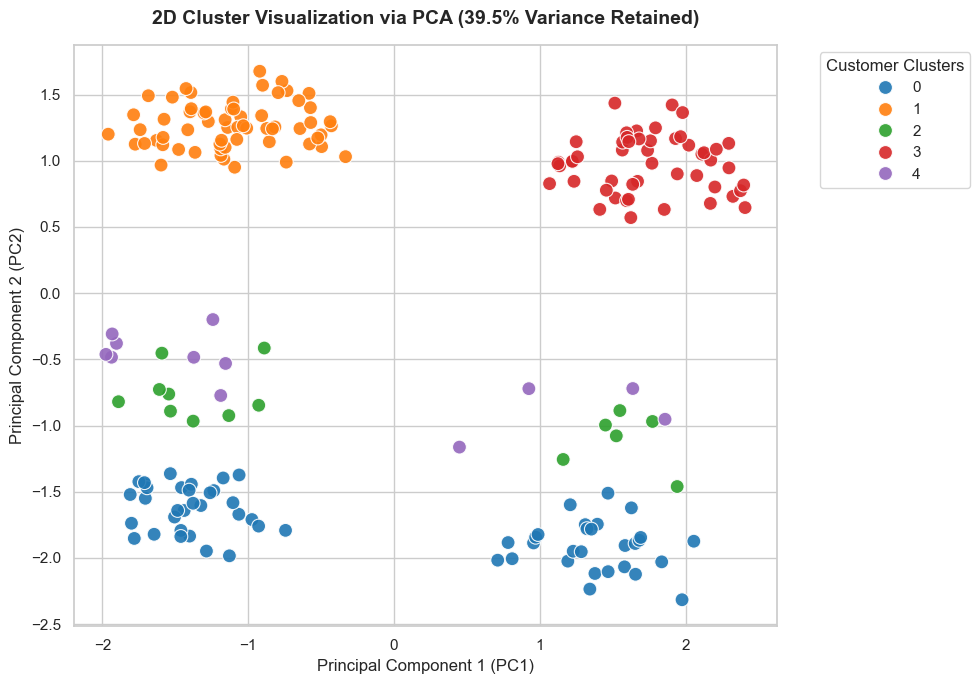

In [21]:

pca = PCA(n_components=2, random_state=42)

features_to_pca = df_scaled.drop(columns=['Cluster'], errors='ignore')
pca_features = pca.fit_transform(features_to_pca)

df_pca = pd.DataFrame(pca_features, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df_scaled['Cluster'].values

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_pca, 
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    palette='tab10', 
    alpha=0.9, 
    edgecolor='w', 
    s=100
)

variance_retained = pca.explained_variance_ratio_.sum() * 100
plt.title(f'2D Cluster Visualization via PCA ({variance_retained:.1f}% Variance Retained)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)
plt.legend(title='Customer Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()